
# Autism Trends in Israel and the U.S. — Summary, Data, and Visual Analysis

**Scope:** recent autism spectrum disorder (ASD) prevalence and identification trends in the United States and Israel, with attention to diagnosis terminology, age, sex/gender patterns, and data limitations.

**Important framing:** these charts mostly show *identified ASD prevalence* or *diagnosis/benefit eligibility rates*. They do **not** directly prove that the underlying biological incidence of autism changed by the same amount. Increases can reflect broader diagnostic criteria, improved awareness, better screening, service incentives, reduced stigma, administrative definitions, and real changes in risk or survival.

**Main sources used in this notebook**

1. Official CDC ASD data page: ADDM Network identified prevalence table, surveillance years 2000–2022, 8-year-old children.  
   Source: https://www.cdc.gov/autism/data-research/index.html
2. Official CDC MMWR Surveillance Summary, 2025: prevalence and early identification among 4- and 8-year-olds in 2022.  
   Source: https://www.cdc.gov/mmwr/volumes/74/ss/ss7402a1.htm  
3. JAMA Network Open / Mental Health Research Network, 2011–2022 U.S. health system diagnosis rates.  
4. Dinstein et al., *Large increase in ASD prevalence in Israel between 2017 and 2021*, using National Insurance Institute and Clalit Health Services data.  
5. Israel Ministry of Health / ALUT summary data on diagnosed children and adolescents.  
6. OECD 2026 policy chapter on rising autism diagnoses in Israel.  
7. Taub Center 2026 summary on timing of autism recognition in Israeli population groups.  
8. OAR summary of Epic Research 2025 EHR analysis on age at first diagnosis by sex. This source is useful for visualization but should be treated as non-peer-reviewed.

All numeric values below are stored explicitly in data frames so the notebook is transparent and reproducible.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def add_value_labels(ax, fmt="{:.1f}", rotation=0, dy=0):
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(fmt.format(h), 
                        (p.get_x() + p.get_width()/2, h), 
                        ha="center", va="bottom",
                        xytext=(0, dy), textcoords="offset points",
                        rotation=rotation, fontsize=9)

def pct_change(first, last):
    return (last / first - 1) * 100

def cagr(first, last, years):
    return (last / first) ** (1 / years) - 1


Matplotlib is building the font cache; this may take a moment.


In [2]:

# -----------------------------
# U.S. CDC ADDM historical trend
# -----------------------------
us_addm = pd.DataFrame({
    "surveillance_year": [2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022],
    "birth_year":        [1992, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014],
    "sites":             [6,    14,   8,    11,   14,   11,   11,   11,   11,   11,   11,   16],
    "prevalence_per_1000_8yo": [6.7, 6.6, 8.0, 9.0, 11.3, 14.7, 14.5, 16.8, 18.5, 23.0, 27.6, 32.2],
    "approx_one_in":     [150, 150, 125, 110, 88, 68, 69, 59, 54, 44, 36, 31],
    "source": "CDC ADDM historical table; 2022 MMWR update"
})
us_addm["prevalence_percent"] = us_addm["prevalence_per_1000_8yo"] / 10

# -----------------------------
# U.S. CDC ADDM 2022 site variation
# -----------------------------
us_sites_2022 = pd.DataFrame({
    "site": ["Arizona", "Arkansas", "California", "Georgia", "Indiana", "Maryland", "Minnesota", "Missouri",
             "New Jersey", "Pennsylvania", "Puerto Rico", "Tennessee", "Texas (Austin)", "Texas (Laredo)",
             "Utah", "Wisconsin"],
    "prevalence_per_1000_8yo": [31.3, 29.8, 53.1, 32.6, 18.3, 26.3, 35.5, 32.1,
                                34.0, 47.4, 26.4, 34.0, 19.5, 9.7, 27.0, 38.4],
    "cases": [210, 457, 807, 1149, 241, 558, 616, 640, 623, 335, 461, 889, 85, 47, 658, 1078],
    "population": [6709, 15319, 15212, 35213, 13155, 21206, 17331, 19968,
                   18334, 7066, 17457, 26182, 4356, 4856, 24395, 28098],
    "source": "CDC MMWR 2025, Table 1"
}).sort_values("prevalence_per_1000_8yo", ascending=False)

# -----------------------------
# U.S. CDC ADDM 2022 sex and race/ethnicity
# -----------------------------
us_sex_2022 = pd.DataFrame({
    "group": ["Boys", "Girls"],
    "prevalence_per_1000_8yo": [49.2, 14.3],
    "source": "CDC MMWR 2025, Table 2"
})

us_race_2022 = pd.DataFrame({
    "group": ["Asian/Pacific Islander", "Black", "Hispanic", "Multiracial", "White", "American Indian/Alaska Native"],
    "prevalence_per_1000_8yo": [38.2, 36.6, 33.0, 31.9, 27.7, 37.5],
    "source": "CDC MMWR 2025, Table 2"
}).sort_values("prevalence_per_1000_8yo", ascending=False)

# -----------------------------
# U.S. JAMA/MHRN 2022 diagnosis rates by age group
# -----------------------------
us_age_2022 = pd.DataFrame({
    "age_group": ["0–4", "5–8", "9–12", "13–17", "18–25", "26–34", "35–44", "45–54", "55–64", "65+"],
    "diagnosis_rate_per_1000": [28.8, 30.3, 22.1, 17.0, 9.5, 3.7, 1.3, 0.6, 0.4, 0.2],
    "source": "JAMA Network Open / MHRN, 2022"
})

us_mhrn_sex_2022 = pd.DataFrame({
    "group": ["Male", "Female"],
    "diagnosis_rate_per_1000": [9.8, 3.1],
    "source": "JAMA Network Open / MHRN, 2022"
})

# -----------------------------
# Israel trend among 8-year-olds
# -----------------------------
israel_8yo = pd.DataFrame({
    "year": [2008, 2015, 2018, 2021],
    "prevalence_percent_8yo": [0.30, 0.65, 1.30, 1.56],
    "prevalence_per_1000_8yo": [3.0, 6.5, 13.0, 15.6],
    "source": ["Prior Israel estimates summarized by Dinstein et al."] * 4
})

# -----------------------------
# Israel NII age-group change 2017 to 2021
# -----------------------------
israel_age_groups = pd.DataFrame({
    "age_group": ["2–3", "4–6", "8"],
    "prevalence_2017_percent": [0.27, 0.80, 0.82],
    "prevalence_2021_percent": [1.19, 1.83, 1.56],
    "source": "Dinstein et al. / NII data"
})
israel_age_long = israel_age_groups.melt(
    id_vars=["age_group", "source"],
    value_vars=["prevalence_2017_percent", "prevalence_2021_percent"],
    var_name="year",
    value_name="prevalence_percent"
)
israel_age_long["year"] = israel_age_long["year"].str.extract("(2017|2021)").astype(int)

# -----------------------------
# Israel child/adolescent summary snapshots
# -----------------------------
israel_summary = pd.DataFrame({
    "metric": ["Children/adolescents diagnosed with ASD", "Child/adolescent prevalence", "Male:female ratio", "School system ASD rate"],
    "year": [2023, 2022, 2022, 2025],
    "value": [37000, 1.13, 4.0, 20.0],
    "unit": ["count", "percent", "ratio", "per 1,000"],
    "source": ["Israel Ministry of Health / ALUT",
               "Ferman et al. 2024",
               "Ferman et al. 2024",
               "Taub Center 2026"]
})

# -----------------------------
# Israel community differences in age/recognition
# -----------------------------
israel_community_recognition = pd.DataFrame({
    "population_group": ["Non-Haredi Jewish neighborhoods", "Haredi neighborhoods", "Arab sector"],
    "recognition_age_years": [2.7, 4.7, np.nan],
    "identified_rate_percent": [1.9, 0.9, 0.8],
    "source": "Taub Center 2026 summary"
})

# -----------------------------
# U.S. sex-specific age at first diagnosis, non-peer-reviewed EHR analysis summarized by OAR
# -----------------------------
diagnosis_age_sex = pd.DataFrame({
    "sex": ["Male", "Male", "Female", "Female"],
    "year": [2015, 2024, 2015, 2024],
    "median_age_at_first_diagnosis": [7, 5, 8, 8],
    "average_age_at_first_diagnosis": [10, 9, 12, 13],
    "source": "OAR summary of Epic Research EHR analysis, 338,415 records; non-peer-reviewed"
})

# -----------------------------
# DSM terminology milestones
# -----------------------------
terminology_timeline = pd.DataFrame({
    "year": [1980, 1994, 2013],
    "manual_or_term": ["DSM-III", "DSM-IV", "DSM-5"],
    "classification_shift": [
        "Autism appears as infantile autism / pervasive developmental disorder framing",
        "Separate PDD categories, including autistic disorder, Asperger's disorder, PDD-NOS",
        "Single Autism Spectrum Disorder diagnosis; severity/support levels added"
    ]
})

print("Loaded data frames:")
for name, df in {
    "us_addm": us_addm,
    "us_sites_2022": us_sites_2022,
    "us_sex_2022": us_sex_2022,
    "us_age_2022": us_age_2022,
    "israel_8yo": israel_8yo,
    "israel_age_groups": israel_age_groups,
    "diagnosis_age_sex": diagnosis_age_sex,
}.items():
    print(f"- {name}: {df.shape[0]} rows")


Loaded data frames:
- us_addm: 12 rows
- us_sites_2022: 16 rows
- us_sex_2022: 2 rows
- us_age_2022: 10 rows
- israel_8yo: 4 rows
- israel_age_groups: 3 rows
- diagnosis_age_sex: 4 rows



## Executive interpretation

### What is increasing?

The clearest trend is an increase in **identified ASD prevalence**. In the U.S. CDC ADDM data, identified ASD among 8-year-olds rose from about **6.7 per 1,000 in 2000** to **32.2 per 1,000 in 2022**. In Israel, the comparable 8-year-old estimates summarized by Dinstein et al. rose from **0.3% in 2008** to **1.56% in 2021**.

### Does this mean autism itself is biologically becoming five times more common?

Not necessarily. These datasets measure identified prevalence. The rise is very likely a combination of:

- broader diagnostic boundaries and DSM-5 spectrum framing;
- earlier screening and improved clinician/school recognition;
- more diagnosis among children without intellectual disability;
- narrowing racial/ethnic and sex/gender ascertainment gaps;
- more adult and female diagnoses;
- administrative and service-access incentives;
- possibly some real environmental, perinatal, genetic-risk-expression, or demographic contributions.

### U.S. vs Israel

The U.S. has deeper public surveillance data, especially through CDC ADDM. Israel has fewer public longitudinal datasets, but the available administrative data show a sharp rise. Israel is especially interesting because the welfare, therapy, and education systems are highly diagnosis-driven: once a formal ASD diagnosis is obtained, the child may unlock substantial support. That can improve access, but can also increase pressure on diagnostic pipelines and create inequities between groups with different access to diagnosis.


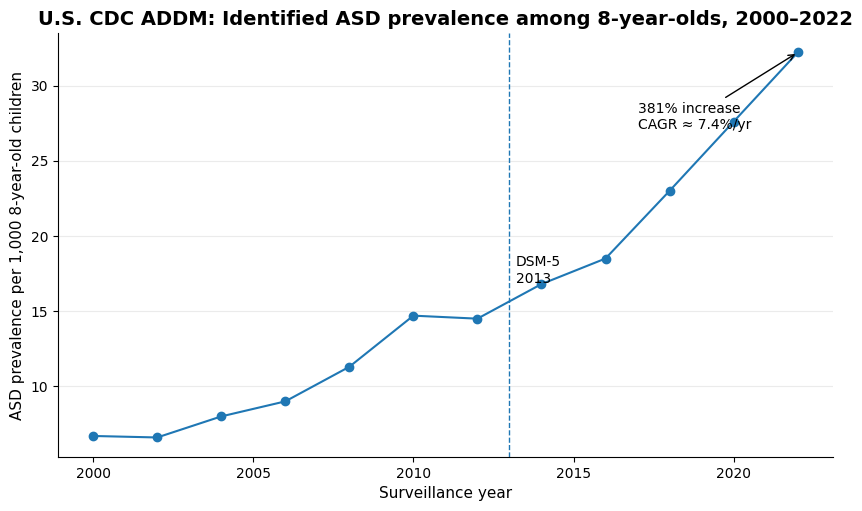

,surveillance_year,birth_year,sites,prevalence_per_1000_8yo,approx_one_in,source,prevalence_percent
0,2000,1992,6,6.7,150,CDC ADDM historical table; 2022 MMWR update,0.67
1,2002,1994,14,6.6,150,CDC ADDM historical table; 2022 MMWR update,0.66
2,2004,1996,8,8.0,125,CDC ADDM historical table; 2022 MMWR update,0.80
3,2006,1998,11,9.0,110,CDC ADDM historical table; 2022 MMWR update,0.90
4,2008,2000,14,11.3,88,CDC ADDM historical table; 2022 MMWR update,1.13
5,2010,2002,11,14.7,68,CDC ADDM historical table; 2022 MMWR update,1.47
6,2012,2004,11,14.5,69,CDC ADDM historical table; 2022 MMWR update,1.45
7,2014,2006,11,16.8,59,CDC ADDM historical table; 2022 MMWR update,1.68
8,2016,2008,11,18.5,54,CDC ADDM historical table; 2022 MMWR update,1.85
9,2018,2010,11,23.0,44,CDC ADDM historical table; 2022 MMWR update,2.30


In [3]:

fig, ax = plt.subplots()
ax.plot(us_addm["surveillance_year"], us_addm["prevalence_per_1000_8yo"], marker="o")
ax.axvline(2013, linestyle="--", linewidth=1)
ax.text(2013.2, us_addm["prevalence_per_1000_8yo"].max()*0.55, "DSM-5\n2013", va="center")
ax.set_title("U.S. CDC ADDM: Identified ASD prevalence among 8-year-olds, 2000–2022")
ax.set_xlabel("Surveillance year")
ax.set_ylabel("ASD prevalence per 1,000 8-year-old children")
ax.grid(axis="y", alpha=0.25)

start, end = us_addm.iloc[0], us_addm.iloc[-1]
growth = pct_change(start["prevalence_per_1000_8yo"], end["prevalence_per_1000_8yo"])
annual = cagr(start["prevalence_per_1000_8yo"], end["prevalence_per_1000_8yo"], end["surveillance_year"] - start["surveillance_year"])
ax.annotate(f"{growth:.0f}% increase\nCAGR ≈ {annual*100:.1f}%/yr",
            xy=(end["surveillance_year"], end["prevalence_per_1000_8yo"]),
            xytext=(-115, -55), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1))
plt.show()

us_addm


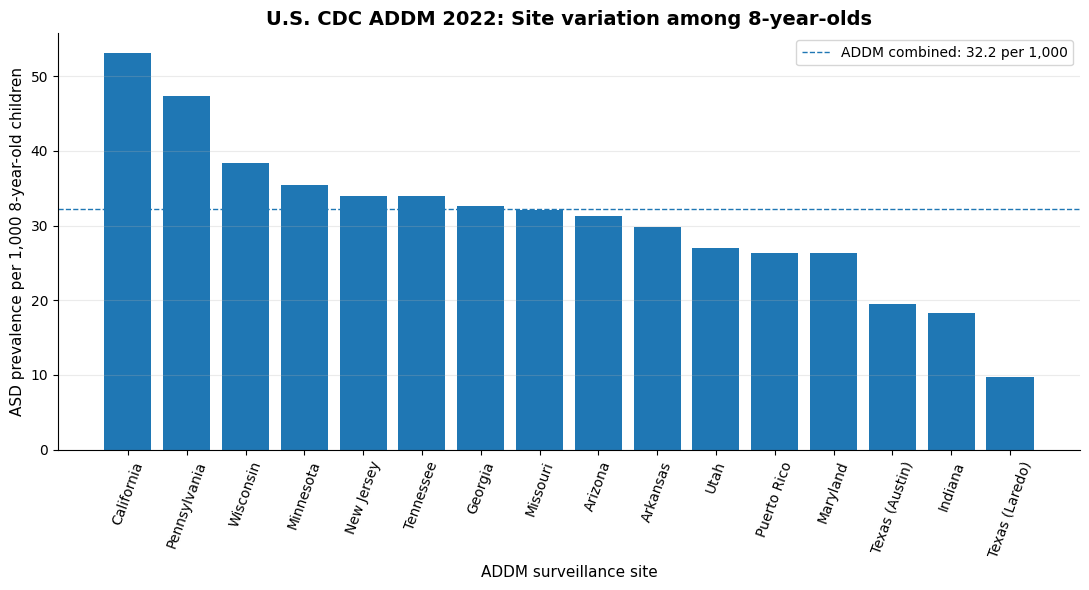

,site,prevalence_per_1000_8yo,cases,population,source
2,California,53.1,807,15212,"CDC MMWR 2025, Table 1"
9,Pennsylvania,47.4,335,7066,"CDC MMWR 2025, Table 1"
15,Wisconsin,38.4,1078,28098,"CDC MMWR 2025, Table 1"
6,Minnesota,35.5,616,17331,"CDC MMWR 2025, Table 1"
8,New Jersey,34.0,623,18334,"CDC MMWR 2025, Table 1"
11,Tennessee,34.0,889,26182,"CDC MMWR 2025, Table 1"
3,Georgia,32.6,1149,35213,"CDC MMWR 2025, Table 1"
7,Missouri,32.1,640,19968,"CDC MMWR 2025, Table 1"
0,Arizona,31.3,210,6709,"CDC MMWR 2025, Table 1"
1,Arkansas,29.8,457,15319,"CDC MMWR 2025, Table 1"


In [4]:

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(us_sites_2022["site"], us_sites_2022["prevalence_per_1000_8yo"])
ax.axhline(32.2, linestyle="--", linewidth=1, label="ADDM combined: 32.2 per 1,000")
ax.set_title("U.S. CDC ADDM 2022: Site variation among 8-year-olds")
ax.set_xlabel("ADDM surveillance site")
ax.set_ylabel("ASD prevalence per 1,000 8-year-old children")
ax.tick_params(axis="x", rotation=70)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

us_sites_2022


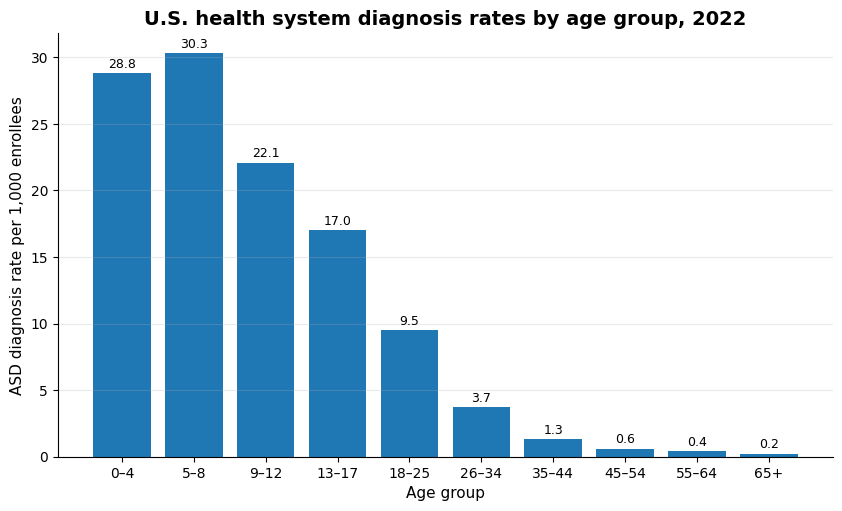

,age_group,diagnosis_rate_per_1000,source
0,0–4,28.8,"JAMA Network Open / MHRN, 2022"
1,5–8,30.3,"JAMA Network Open / MHRN, 2022"
2,9–12,22.1,"JAMA Network Open / MHRN, 2022"
3,13–17,17.0,"JAMA Network Open / MHRN, 2022"
4,18–25,9.5,"JAMA Network Open / MHRN, 2022"
5,26–34,3.7,"JAMA Network Open / MHRN, 2022"
6,35–44,1.3,"JAMA Network Open / MHRN, 2022"
7,45–54,0.6,"JAMA Network Open / MHRN, 2022"
8,55–64,0.4,"JAMA Network Open / MHRN, 2022"
9,65+,0.2,"JAMA Network Open / MHRN, 2022"


In [5]:

fig, ax = plt.subplots()
ax.bar(us_age_2022["age_group"], us_age_2022["diagnosis_rate_per_1000"])
add_value_labels(ax, fmt="{:.1f}", dy=2)
ax.set_title("U.S. health system diagnosis rates by age group, 2022")
ax.set_xlabel("Age group")
ax.set_ylabel("ASD diagnosis rate per 1,000 enrollees")
ax.grid(axis="y", alpha=0.25)
plt.show()

us_age_2022


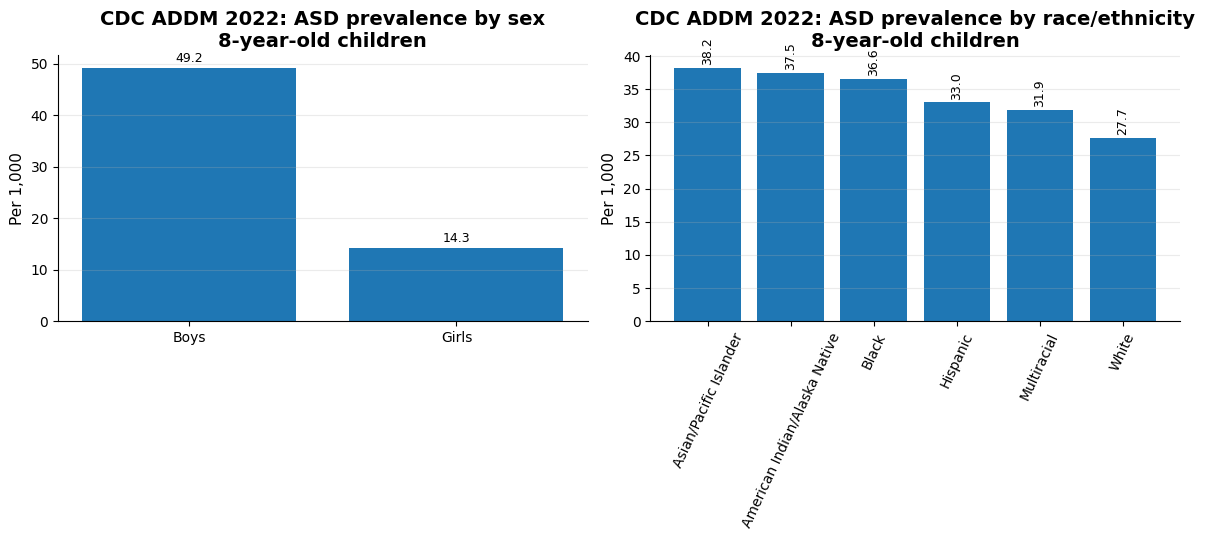

Male:female prevalence ratio in CDC ADDM 2022: 3.44


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].bar(us_sex_2022["group"], us_sex_2022["prevalence_per_1000_8yo"])
add_value_labels(axes[0], fmt="{:.1f}", dy=2)
axes[0].set_title("CDC ADDM 2022: ASD prevalence by sex\n8-year-old children")
axes[0].set_ylabel("Per 1,000")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(us_race_2022["group"], us_race_2022["prevalence_per_1000_8yo"])
add_value_labels(axes[1], fmt="{:.1f}", rotation=90, dy=2)
axes[1].set_title("CDC ADDM 2022: ASD prevalence by race/ethnicity\n8-year-old children")
axes[1].set_ylabel("Per 1,000")
axes[1].tick_params(axis="x", rotation=65)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("Male:female prevalence ratio in CDC ADDM 2022:", round(49.2/14.3, 2))


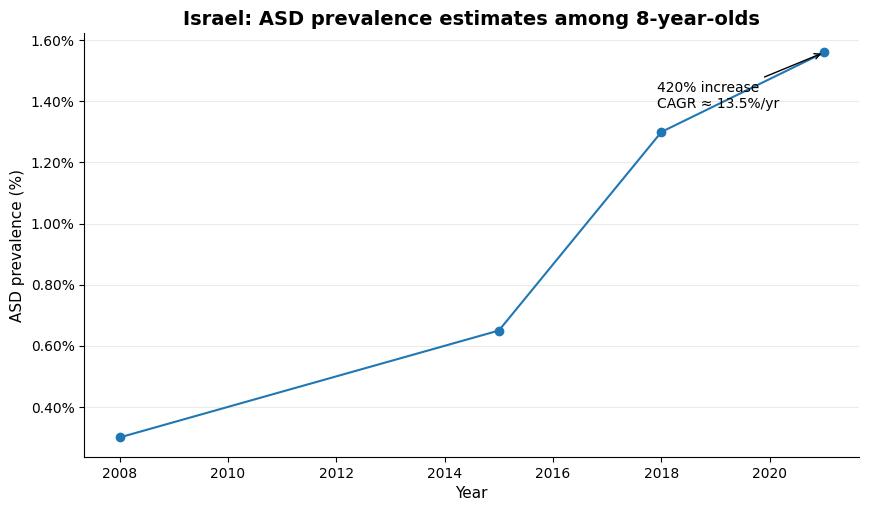

,year,prevalence_percent_8yo,prevalence_per_1000_8yo,source
0,2008,0.30,3.0,Prior Israel estimates summarized by Dinstein ...
1,2015,0.65,6.5,Prior Israel estimates summarized by Dinstein ...
2,2018,1.30,13.0,Prior Israel estimates summarized by Dinstein ...
3,2021,1.56,15.6,Prior Israel estimates summarized by Dinstein ...


In [7]:

fig, ax = plt.subplots()
ax.plot(israel_8yo["year"], israel_8yo["prevalence_percent_8yo"], marker="o")
ax.set_title("Israel: ASD prevalence estimates among 8-year-olds")
ax.set_xlabel("Year")
ax.set_ylabel("ASD prevalence (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(axis="y", alpha=0.25)

start, end = israel_8yo.iloc[0], israel_8yo.iloc[-1]
growth = pct_change(start["prevalence_percent_8yo"], end["prevalence_percent_8yo"])
annual = cagr(start["prevalence_percent_8yo"], end["prevalence_percent_8yo"], end["year"] - start["year"])
ax.annotate(f"{growth:.0f}% increase\nCAGR ≈ {annual*100:.1f}%/yr",
            xy=(end["year"], end["prevalence_percent_8yo"]),
            xytext=(-120, -40), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1))
plt.show()

israel_8yo


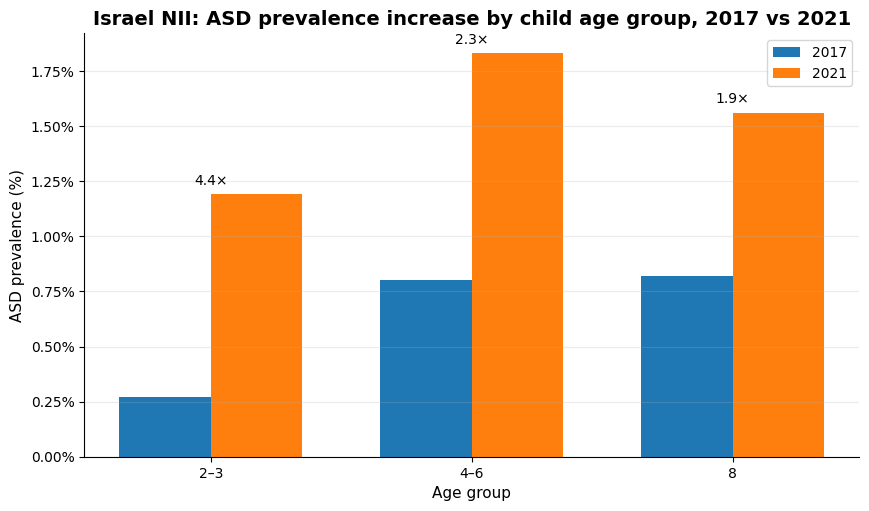

,age_group,prevalence_2017_percent,prevalence_2021_percent,source
0,2–3,0.27,1.19,Dinstein et al. / NII data
1,4–6,0.80,1.83,Dinstein et al. / NII data
2,8,0.82,1.56,Dinstein et al. / NII data


In [8]:

pivot = israel_age_long.pivot(index="age_group", columns="year", values="prevalence_percent")
fig, ax = plt.subplots()
x = np.arange(len(pivot.index))
width = 0.35
ax.bar(x - width/2, pivot[2017], width, label="2017")
ax.bar(x + width/2, pivot[2021], width, label="2021")
ax.set_xticks(x, pivot.index)
ax.set_title("Israel NII: ASD prevalence increase by child age group, 2017 vs 2021")
ax.set_xlabel("Age group")
ax.set_ylabel("ASD prevalence (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend()
ax.grid(axis="y", alpha=0.25)

# Add fold-change labels
for i, group in enumerate(pivot.index):
    fold = pivot.loc[group, 2021] / pivot.loc[group, 2017]
    ax.annotate(f"{fold:.1f}×", (i, pivot.loc[group, 2021]), ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
plt.show()

israel_age_groups


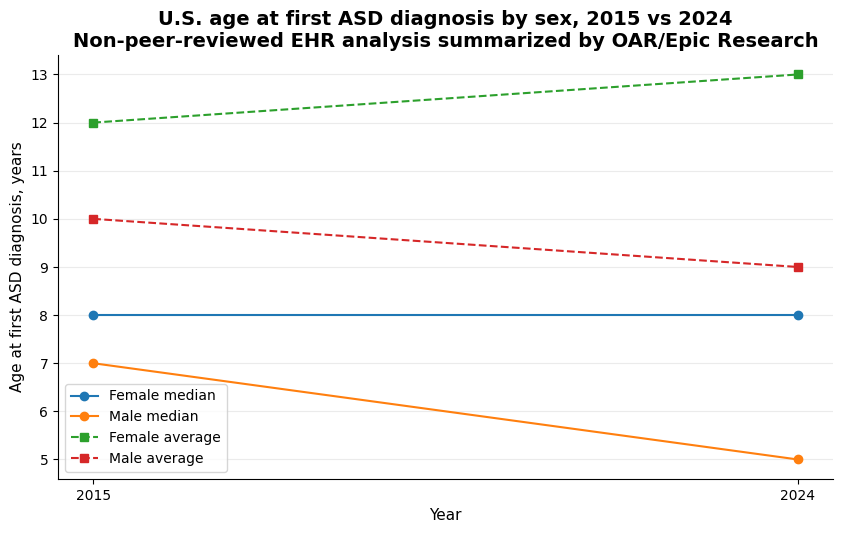

,sex,year,median_age_at_first_diagnosis,average_age_at_first_diagnosis,source
0,Male,2015,7,10,"OAR summary of Epic Research EHR analysis, 338..."
1,Male,2024,5,9,"OAR summary of Epic Research EHR analysis, 338..."
2,Female,2015,8,12,"OAR summary of Epic Research EHR analysis, 338..."
3,Female,2024,8,13,"OAR summary of Epic Research EHR analysis, 338..."


In [9]:

fig, ax = plt.subplots()

# Median ages
for sex, df in diagnosis_age_sex.groupby("sex"):
    ax.plot(df["year"], df["median_age_at_first_diagnosis"], marker="o", label=f"{sex} median")

# Average ages as dashed lines
for sex, df in diagnosis_age_sex.groupby("sex"):
    ax.plot(df["year"], df["average_age_at_first_diagnosis"], marker="s", linestyle="--", label=f"{sex} average")

ax.set_title("U.S. age at first ASD diagnosis by sex, 2015 vs 2024\nNon-peer-reviewed EHR analysis summarized by OAR/Epic Research")
ax.set_xlabel("Year")
ax.set_ylabel("Age at first ASD diagnosis, years")
ax.set_xticks([2015, 2024])
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()

diagnosis_age_sex


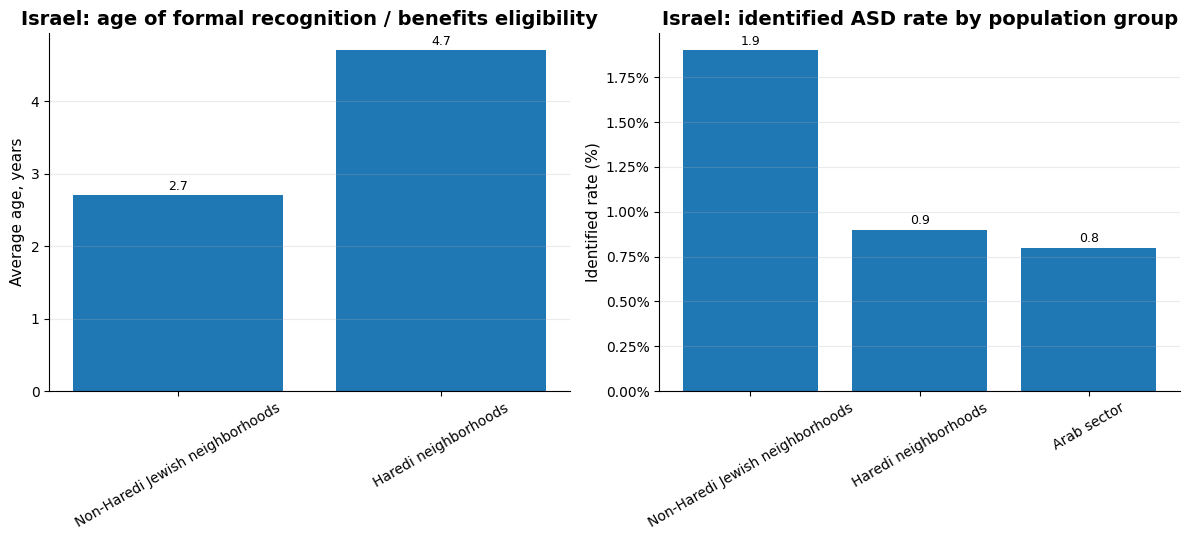

,population_group,recognition_age_years,identified_rate_percent,source
0,Non-Haredi Jewish neighborhoods,2.7,1.9,Taub Center 2026 summary
1,Haredi neighborhoods,4.7,0.9,Taub Center 2026 summary
2,Arab sector,NaN,0.8,Taub Center 2026 summary


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

recog = israel_community_recognition.dropna(subset=["recognition_age_years"])
axes[0].bar(recog["population_group"], recog["recognition_age_years"])
add_value_labels(axes[0], fmt="{:.1f}", dy=2)
axes[0].set_title("Israel: age of formal recognition / benefits eligibility")
axes[0].set_ylabel("Average age, years")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(israel_community_recognition["population_group"], israel_community_recognition["identified_rate_percent"])
add_value_labels(axes[1], fmt="{:.1f}", dy=2)
axes[1].set_title("Israel: identified ASD rate by population group")
axes[1].set_ylabel("Identified rate (%)")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

israel_community_recognition



## Terminology shift: from “Asperger’s” to ASD / Level 1 / support-needs framing

### What changed?

Before DSM-5, clinicians often used separate labels such as **autistic disorder**, **Asperger’s disorder**, and **PDD-NOS**. DSM-5 merged most of these into one diagnosis: **Autism Spectrum Disorder**. The DSM-5 framework asks whether the person meets the core criteria of ASD, then describes severity/support needs, language impairment, intellectual impairment, and associated conditions.

### What happened to “Asperger’s”?

“Asperger’s” is no longer a separate formal DSM-5 diagnosis. Many people who would previously have received Asperger’s are now diagnosed as **ASD, often Level 1**, meaning they require support but may have fluent language and average or above-average measured intelligence.

### What does “high functioning” mean?

“High functioning autism” is informal, not a precise clinical diagnosis. It usually means the person has relatively lower observable support needs in some settings, fluent language, and/or no intellectual disability. The term can be misleading because it may hide serious social, sensory, executive-function, anxiety, school/work, or daily-life challenges. A better research and clinical phrasing is often:

- ASD with or without intellectual disability
- ASD with or without language impairment
- support needs: Level 1 / Level 2 / Level 3
- specific functional profile rather than one global “functioning” label


In [11]:

terminology_timeline


,year,manual_or_term,classification_shift
0,1980,DSM-III,Autism appears as infantile autism / pervasive...
1,1994,DSM-IV,"Separate PDD categories, including autistic di..."
2,2013,DSM-5,Single Autism Spectrum Disorder diagnosis; sev...



## Final synthesis

1. **U.S. trend:** CDC ADDM shows a large, sustained rise in identified ASD prevalence among 8-year-olds from 2000 to 2022. The 2022 estimate is **32.2 per 1,000**, or about **1 in 31**.

2. **Israel trend:** Israel also shows a sharp increase. Among 8-year-olds, available estimates rose from **0.3% in 2008** to **1.56% in 2021**. Among very young children, the rise is even steeper, suggesting a shift toward earlier recognition.

3. **Sex/gender pattern:** Boys are still diagnosed more often, but the male:female gap is narrowing in U.S. health-system data and likely reflects better recognition of autism in girls and women. Girls/females are still often diagnosed later.

4. **Age pattern:** U.S. health-system data show the highest diagnosis rates among children, especially ages 5–8, while adult diagnosis rates are lower but rising quickly among young adults.

5. **Israel-specific interpretation:** Israel’s diagnosis-driven benefits and education system may encourage diagnosis-seeking and creates pressure on public diagnostic capacity. The Taub Center data suggest an “access paradox”: groups with more access to diagnostic pathways are identified earlier and more often, while Haredi, Arab-sector, and low-SES communities may face delays or under-identification.

6. **Caution:** Rising identified prevalence should not be interpreted as a simple biological epidemic. The safer conclusion is: **autism identification has increased strongly, and systems must plan for more autistic children, adolescents, and adults needing individualized supports.**



## Source notes

- Official CDC ADDM historical table 2000–2022: https://www.cdc.gov/autism/data-research/index.html
- Official CDC MMWR 2025 Table 1, 2, 4, 5 for U.S. site variation, sex/race prevalence, diagnosis age, and 4-year-old vs 8-year-old early identification: https://www.cdc.gov/mmwr/volumes/74/ss/ss7402a1.htm
- JAMA Network Open / MHRN 2024 study for U.S. age-group and sex diagnosis rates in 2022.
- Dinstein et al. 2024 for Israel NII/Clalit trends, especially 2017–2021 age-group changes.
- Israel Ministry of Health page citing ALUT data for 2023 diagnosed children/adolescents.
- Ferman et al. 2024 for Israel child/adolescent prevalence, male:female ratio, and typical diagnosis age.
- OECD 2026 Israel autism policy chapter for policy interpretation and system incentives.
- Taub Center 2026 summary for Israeli population-group recognition age and identified-rate gaps.
- OAR summary of Epic Research 2025 for sex-specific median/average age at first diagnosis. This is clearly marked as non-peer-reviewed.
